# Building Your First Artificial Neural Network (ANN)

This project demonstrates how to build a basic ANN using TensorFlow and Keras to predict diabetes based on diagnostic measurements. We will use the **Pima Indians Diabetes Dataset**.

## Project Overview
1. **Data Loading**: Load the CSV dataset.
2. **Data Preprocessing**: Prepare the data for the neural network.
3. **Model Architecture**: Define the ANN using the Sequential API.
4. **Compilation**: Configure the learning process.
5. **Training**: Train the model on the data.
6. **Evaluation**: Assess the model's performance.

In [4]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

## 1. Data Loading
The dataset contains 8 medical predictor variables and one target variable (Outcome).

In [5]:
df=pd.read_csv('C:\\DL\\project 1\\diabetes.csv')
df.columns = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age',
    'Outcome'
]

# Display dataset
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            1       85             66             29        0  26.6   
1            8      183             64              0        0  23.3   
2            1       89             66             23       94  28.1   
3            0      137             40             35      168  43.1   
4            5      116             74              0        0  25.6   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.351   31        0  
1                     0.672   32        1  
2                     0.167   21        0  
3                     2.288   33        1  
4                     0.201   30        0  


## 2. Data Preprocessing
Neural networks perform best when input features are on a similar scale.

In [6]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 3. Model Architecture
We will use the `Sequential` API to stack layers.
- **Input Layer**: 8 features.
- **Hidden Layers**: Dense layers with ReLU activation(3 hidden layers with 12,8,1 consist of relu, relu and output layer sigmoid).
- **Output Layer**: 1 neuron with Sigmoid activation (for binary classification).

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [10]:
model = Sequential()

# First Hidden Layer
model.add(Dense(12, activation='relu', input_dim=8))

# Second Hidden Layer
model.add(Dense(8, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

c:\DL\tfenv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221 (884.00 B)

 Trainable params: 221 (884.00 B)

 Non-trainable params: 0 (0.00 B)

## 4. Compilation
We use `binary_crossentropy` for loss and `adam` as the optimizer.

In [12]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## 5. Training
We train the model for 100 epochs.

In [13]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6551 - loss: 0.8048 - val_accuracy: 0.6667 - val_loss: 0.6785
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6551 - loss: 0.7126 - val_accuracy: 0.6829 - val_loss: 0.6283
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6551 - loss: 0.6499 - val_accuracy: 0.6504 - val_loss: 0.5922
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6673 - loss: 0.6031 - val_accuracy: 0.6667 - val_loss: 0.5677
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6918 - loss: 0.5689 - val_accuracy: 0.6992 - val_loss: 0.5490
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7041 - loss: 0.5467 - val_accuracy: 0.7073 - val_loss: 0.5332
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7184 - loss: 0.5301 - val_accuracy: 0.7480 - val_loss: 0.5216
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7347 - loss: 0.5177 - val_accuracy: 0.7480 -

## 6. Evaluation
Check how the model performs on unseen data.

In [14]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Loss:", loss)
print("Accuracy:", accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7857 - loss: 0.4634 
Loss: 0.463431179523468
Accuracy: 0.7857142686843872


In [15]:
prediction = model.predict(X_test)

print(prediction[:5])

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
[[0.47392905]
 [0.09220671]
 [0.04504128]
 [0.36277148]
 [0.02618435]]


In [16]:
prediction = (prediction > 0.5)

print(prediction[:5])

[[False]
 [False]
 [False]
 [False]
 [False]]


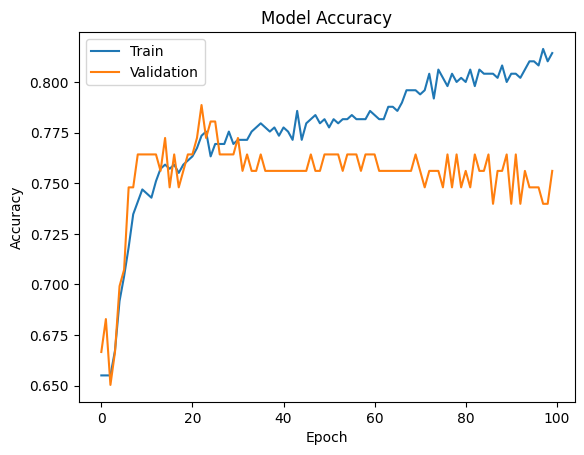

In [17]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

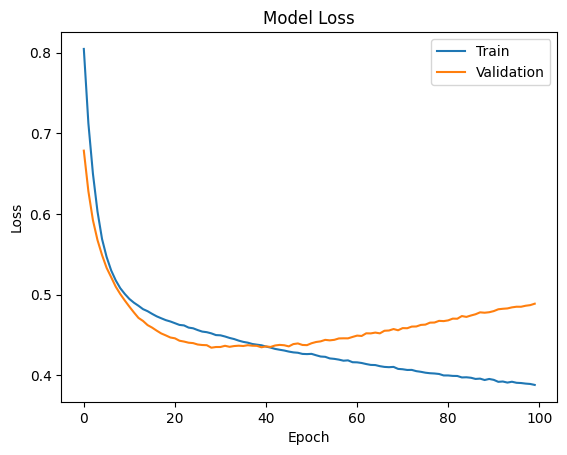

In [18]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()